# Model Comparison — Store Item Demand Forecasting Challenge

Benchmarks baselines, classical statistical models (SARIMA, Prophet), global
gradient boosting (LightGBM, XGBoost), and a global LSTM on the real Kaggle
competition data (10 stores x 50 items, 2013-2017).

**Evaluation protocol:** walk-forward, 3 folds of 28 days each near the end
of the series, expanding training window. Metrics: **SMAPE, MAE, RMSE** —
appropriate here since (per the EDA notebook) this dataset is dense,
non-intermittent demand, unlike M5.

**One disclosed compute tradeoff:** SARIMA/Prophet are fit per series, which
doesn't scale to fitting+forecasting 500 series x 3 folds in a reasonable
time on a single machine. They're evaluated on a **fixed random sample of 40
series** (stratified nowhere — just a plain random sample, seeded for
reproducibility), not the full 500. The LSTM is evaluated on a **single**
28-day holdout fold rather than all 3, since retraining a neural model per
fold triples an already-heavier cost. Baselines and the two gradient
boosting models run on the **full 500 series, all 3 folds** — that's the
comparison that should be trusted most.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("setup complete")

setup complete


## 1. Load data and build features (leakage-safe, same as the EDA notebook)

In [2]:
INPUT_DIR = "/kaggle/input/demand-forecasting-kernels-only"
import os
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = "data"

train = pd.read_csv(f"{INPUT_DIR}/train.csv", parse_dates=["date"])
print("train:", train.shape)

def build_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.sort_values(["store","item","date"]).copy()
    d["dow"]        = d.date.dt.dayofweek
    d["is_weekend"] = (d["dow"] >= 5).astype("int8")
    d["month"]      = d.date.dt.month
    d["weekofyear"] = d.date.dt.isocalendar().week.astype("int16")
    d["year"]       = d.date.dt.year
    d["dayofyear"]  = d.date.dt.dayofyear
    g = d.groupby(["store","item"], group_keys=False)
    for lag in [1, 7, 14, 28, 364]:
        d[f"sales_lag_{lag}"] = g["sales"].shift(lag)
    sh = g["sales"].shift(1)
    for w in [7, 28, 90]:
        d[f"sales_rmean_{w}"] = sh.groupby([d.store, d.item]).transform(lambda s: s.rolling(w).mean())
        d[f"sales_rstd_{w}"]  = sh.groupby([d.store, d.item]).transform(lambda s: s.rolling(w).std())
    d["store_code"] = d["store"].astype("category").cat.codes
    d["item_code"]  = d["item"].astype("category").cat.codes
    return d

FEATURES = ["store_code","item_code","dow","is_weekend","month","weekofyear","year","dayofyear",
            "sales_lag_1","sales_lag_7","sales_lag_14","sales_lag_28","sales_lag_364",
            "sales_rmean_7","sales_rstd_7","sales_rmean_28","sales_rstd_28",
            "sales_rmean_90","sales_rstd_90"]
TARGET = "sales"

feat = build_features(train)
feat_c = feat.dropna(subset=FEATURES).reset_index(drop=True)
print("usable rows after dropping incomplete lag history:", feat_c.shape)

train: (913000, 4)


usable rows after dropping incomplete lag history: (731000, 23)


## 2. Walk-forward folds and metrics

Three 28-day test windows near the end of the series, expanding training
window per fold — same protocol as the M5 project, so the discipline
carries over even though this dataset behaves very differently.

In [3]:
max_date = feat_c["date"].max()
FOLD_DAYS = 28
N_FOLDS = 3
folds = []
for k in range(N_FOLDS):
    test_end   = max_date - pd.Timedelta(days=FOLD_DAYS * k)
    test_start = test_end - pd.Timedelta(days=FOLD_DAYS - 1)
    folds.append((test_start, test_end))
folds = folds[::-1]  # chronological order
for i, (s, e) in enumerate(folds, 1):
    print(f"fold {i}: test {s.date()} -> {e.date()}")

def smape(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    denom = (np.abs(y) + np.abs(p))
    denom = np.where(denom == 0, 1, denom)
    return float(np.mean(2 * np.abs(p - y) / denom) * 100)

def mae(y, p):
    return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(p, float))))

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(p, float)) ** 2)))

def score(y, p):
    p = np.clip(np.asarray(p, float), 0, None)
    return {"SMAPE": round(smape(y, p), 3), "MAE": round(mae(y, p), 3), "RMSE": round(rmse(y, p), 3)}

results = []  # collects one row per (model, fold) for the final leaderboard

fold 1: test 2017-10-09 -> 2017-11-05
fold 2: test 2017-11-06 -> 2017-12-03
fold 3: test 2017-12-04 -> 2017-12-31


## 3. Tier 0 — Baselines (full 500 series, all 3 folds)

- **Naive**: yesterday's value (`sales_lag_1`)
- **Seasonal naive**: same weekday last week (`sales_lag_7`)
- **Moving average**: trailing 28-day mean (`sales_rmean_28`)

These already exist as features, so no extra fitting needed — just read the
column and score it against the actual.

In [4]:
for i, (s, e) in enumerate(folds, 1):
    te = feat_c[(feat_c.date >= s) & (feat_c.date <= e)]
    for name, col in [("Naive", "sales_lag_1"),
                       ("SeasonalNaive_7d", "sales_lag_7"),
                       ("MovingAvg_28d", "sales_rmean_28")]:
        m = score(te[TARGET], te[col])
        results.append({"model": name, "tier": "baseline", "fold": i, "n": len(te), **m})

pd.DataFrame(results)[["model","fold","n","SMAPE","MAE","RMSE"]]

,model,fold,n,SMAPE,MAE,RMSE
0,Naive,1,14000,20.895,11.195,15.165
1,SeasonalNaive_7d,1,14000,16.759,8.515,10.976
2,MovingAvg_28d,1,14000,16.663,9.092,11.871
3,Naive,2,14000,21.086,11.765,16.018
4,SeasonalNaive_7d,2,14000,18.180,9.923,13.292
5,MovingAvg_28d,2,14000,16.250,9.143,11.997
6,Naive,3,14000,22.963,9.288,12.460
7,SeasonalNaive_7d,3,14000,21.123,8.742,11.803
8,MovingAvg_28d,3,14000,23.616,10.527,13.908


## 4. Tier 1 — Classical per-series models (SARIMA, Prophet)

Sampled 40 series (seeded) x 3 folds. Each series gets its own model fit on
history strictly before the fold's test window, then forecasts the 28 test
days directly (no re-fitting mid-window).

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

rng = np.random.default_rng(RANDOM_STATE)
all_series = train[["store","item"]].drop_duplicates().reset_index(drop=True)
sample_series = all_series.sample(n=40, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"sampled {len(sample_series)} of {len(all_series)} series for SARIMA/Prophet")

sarima_rows, sarima_fail = [], 0
for i, (fold_start, fold_end) in enumerate(folds, 1):
    y_true_all, y_pred_all = [], []
    for _, r in sample_series.iterrows():
        # NOTE: use r["item"], NOT r.item -- dot access collides with the
        # built-in Series.item() method and silently matches nothing.
        s = train[(train.store == r["store"]) & (train.item == r["item"])].sort_values("date")
        y = s.set_index("date")["sales"].asfreq("D")
        y_tr = y[y.index < fold_start]
        y_te = y[(y.index >= fold_start) & (y.index <= fold_end)]
        if len(y_te) == 0 or len(y_tr) < 90:
            continue
        try:
            mod = SARIMAX(y_tr, order=(1,1,1), seasonal_order=(1,1,1,7),
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            fc = res.forecast(steps=len(y_te))
            y_true_all.extend(y_te.values); y_pred_all.extend(fc.values)
        except Exception:
            sarima_fail += 1
    assert len(y_true_all) > 0, f"fold {i}: 0 points scored -- series matching or date filtering is broken"
    m = score(y_true_all, y_pred_all)
    sarima_rows.append({"model": "SARIMA", "tier": "classical", "fold": i, "n": len(y_true_all), **m})
    print(f"fold {i} SARIMA done ({len(y_true_all)} points, {sarima_fail} cumulative fit failures)")

results.extend(sarima_rows)
pd.DataFrame(sarima_rows)

sampled 40 of 500 series for SARIMA/Prophet


fold 1 SARIMA done (1120 points, 0 cumulative fit failures)


fold 2 SARIMA done (1120 points, 0 cumulative fit failures)


fold 3 SARIMA done (1120 points, 0 cumulative fit failures)


,model,tier,fold,n,SMAPE,MAE,RMSE
0,SARIMA,classical,1,1120,12.859,6.315,8.196
1,SARIMA,classical,2,1120,14.318,7.585,10.227
2,SARIMA,classical,3,1120,25.049,10.678,12.984


In [6]:
from prophet import Prophet

prophet_rows = []
for i, (fold_start, fold_end) in enumerate(folds, 1):
    y_true_all, y_pred_all = [], []
    for _, r in sample_series.iterrows():
        s = train[(train.store == r["store"]) & (train.item == r["item"])].sort_values("date")
        s_tr = s[s.date < fold_start][["date","sales"]].rename(columns={"date":"ds","sales":"y"})
        s_te = s[(s.date >= fold_start) & (s.date <= fold_end)]
        if len(s_te) == 0 or len(s_tr) < 90:
            continue
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
        m.fit(s_tr)
        fut = m.make_future_dataframe(periods=len(s_te), include_history=False)
        fc = m.predict(fut)
        y_true_all.extend(s_te["sales"].values); y_pred_all.extend(fc["yhat"].values)
    assert len(y_true_all) > 0, f"fold {i}: 0 points scored -- series matching or date filtering is broken"
    sc = score(y_true_all, y_pred_all)
    prophet_rows.append({"model": "Prophet", "tier": "classical", "fold": i, "n": len(y_true_all), **sc})
    print(f"fold {i} Prophet done ({len(y_true_all)} points)")

results.extend(prophet_rows)
pd.DataFrame(prophet_rows)

Importing plotly failed. Interactive plots will not work.


21:06:45 - cmdstanpy - INFO - Chain [1] start processing


21:06:45 - cmdstanpy - INFO - Chain [1] done processing


21:06:46 - cmdstanpy - INFO - Chain [1] start processing


21:06:46 - cmdstanpy - INFO - Chain [1] done processing


...

21:07:15 - cmdstanpy - INFO - Chain [1] done processing


21:07:15 - cmdstanpy - INFO - Chain [1] start processing


21:07:15 - cmdstanpy - INFO - Chain [1] done processing


fold 3 Prophet done (1120 points)


,model,tier,fold,n,SMAPE,MAE,RMSE
0,Prophet,classical,1,1120,12.321,5.976,7.730
1,Prophet,classical,2,1120,13.330,6.921,8.957
2,Prophet,classical,3,1120,14.774,5.674,7.482


## 5. Tier 2 — Global gradient boosting (LightGBM, XGBoost)

Full 500 series, all 3 folds, retrained per fold on all history strictly
before that fold's test window (expanding window, no leakage).

In [7]:
import lightgbm as lgb
import xgboost as xgb

gbm_rows = []
for i, (fold_start, fold_end) in enumerate(folds, 1):
    tr = feat_c[feat_c.date < fold_start]
    te = feat_c[(feat_c.date >= fold_start) & (feat_c.date <= fold_end)]

    lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=RANDOM_STATE, verbose=-1)
    lgbm.fit(tr[FEATURES], tr[TARGET])
    sc = score(te[TARGET], lgbm.predict(te[FEATURES]))
    gbm_rows.append({"model": "LightGBM", "tier": "gbm", "fold": i, "n": len(te), **sc})

    xgbm = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, verbosity=0)
    xgbm.fit(tr[FEATURES], tr[TARGET])
    sc = score(te[TARGET], xgbm.predict(te[FEATURES]))
    gbm_rows.append({"model": "XGBoost", "tier": "gbm", "fold": i, "n": len(te), **sc})
    print(f"fold {i} gradient boosting done")

results.extend(gbm_rows)
pd.DataFrame(gbm_rows)

fold 1 gradient boosting done


fold 2 gradient boosting done


fold 3 gradient boosting done


,model,tier,fold,n,SMAPE,MAE,RMSE
0,LightGBM,gbm,1,14000,11.973,6.122,7.905
1,XGBoost,gbm,1,14000,11.921,6.099,7.878
2,LightGBM,gbm,2,14000,11.813,6.219,8.048
3,XGBoost,gbm,2,14000,11.732,6.186,8.012
4,LightGBM,gbm,3,14000,13.805,5.383,6.986
5,XGBoost,gbm,3,14000,13.706,5.340,6.922


## 6. Tier 3 — Global LSTM

One shared LSTM across all 500 series (store/item identity via embeddings),
trained on scaled per-series sales. **Single 28-day holdout fold** (the most
recent one) rather than all 3 — see the compute-tradeoff note at the top.
Per-series scaling (mean/std) is computed on the training portion only, to
avoid leaking test-period statistics into the input.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_STATE)

piv = train.pivot(index="date", columns=["store","item"], values="sales")
dates = piv.index
arr = piv.values.astype("float32")
T, N = arr.shape

fold_start, fold_end = folds[-1]           # most recent fold only
cut_idx = int(np.searchsorted(dates, fold_start))

mean = arr[:cut_idx].mean(axis=0, keepdims=True)
std  = arr[:cut_idx].std(axis=0, keepdims=True) + 1e-6
arr_s = (arr - mean) / std

SEQ = 28
X_list, Y_list = [], []
for t in range(SEQ, T):
    X_list.append(arr_s[t-SEQ:t, :]); Y_list.append(arr_s[t, :])
X = np.stack(X_list); Y = np.stack(Y_list)
t_idx = np.arange(SEQ, T)
is_train = t_idx < cut_idx
is_test  = (dates[t_idx] >= fold_start) & (dates[t_idx] <= fold_end)

Xtr = X[is_train].transpose(0,2,1).reshape(-1, SEQ, 1)
Ytr = Y[is_train].reshape(-1)
sid_tr = np.tile(np.arange(N), is_train.sum())

Xte = X[is_test].transpose(0,2,1).reshape(-1, SEQ, 1)
Yte = Y[is_test].reshape(-1)
sid_te = np.tile(np.arange(N), is_test.sum())
print("train sequences:", Xtr.shape, "| test sequences:", Xte.shape)

class GlobalLSTM(nn.Module):
    def __init__(self, n_series, emb_dim=8, hidden=32):
        super().__init__()
        self.emb = nn.Embedding(n_series, emb_dim)
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden+emb_dim, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x, sid):
        _, (h, _) = self.lstm(x)
        return self.head(torch.cat([h[-1], self.emb(sid)], dim=1)).squeeze(-1)

model = GlobalLSTM(N)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossfn = nn.MSELoss()

ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Ytr), torch.from_numpy(sid_tr).long())
dl = DataLoader(ds, batch_size=1024, shuffle=True)

EPOCHS = 5
for ep in range(EPOCHS):
    model.train(); total = 0.0; nb = 0
    for xb, yb, sb in dl:
        opt.zero_grad()
        pred = model(xb, sb)
        loss = lossfn(pred, yb)
        loss.backward(); opt.step()
        total += loss.item(); nb += 1
    print(f"epoch {ep+1}/{EPOCHS}  train MSE (scaled): {total/nb:.4f}")

model.eval()
with torch.no_grad():
    pred_s = model(torch.from_numpy(Xte), torch.from_numpy(sid_te).long()).numpy()

# undo per-series scaling: mean/std are (1,N), sid_te indexes which series each row is
pred_unscaled = pred_s * std[0, sid_te] + mean[0, sid_te]
true_unscaled = Yte * std[0, sid_te] + mean[0, sid_te]

sc = score(true_unscaled, pred_unscaled)
results.append({"model": "LSTM", "tier": "neural", "fold": 3, "n": len(true_unscaled), **sc})
print("LSTM fold-3 result:", sc)

train sequences: (885000, 28, 1) | test sequences: (14000, 28, 1)


epoch 1/5  train MSE (scaled): 0.5032


epoch 2/5  train MSE (scaled): 0.3378


epoch 3/5  train MSE (scaled): 0.3303


epoch 4/5  train MSE (scaled): 0.3285


epoch 5/5  train MSE (scaled): 0.3272


LSTM fold-3 result: {'SMAPE': 15.956, 'MAE': 6.356, 'RMSE': 8.278}


## 7. Leaderboard

Averaged across the folds each model actually ran on — baselines and
gradient boosting are averaged over all 3 folds; SARIMA/Prophet over their 3
sampled-series folds; LSTM has only 1 fold, shown as-is (**not directly
comparable in robustness to the 3-fold numbers**, just the best single
estimate available given the compute budget).

In [9]:
res_df = pd.DataFrame(results)
leaderboard = (res_df.groupby(["model","tier"])
               .agg(folds_evaluated=("fold","nunique"),
                    total_points=("n","sum"),
                    SMAPE=("SMAPE","mean"), MAE=("MAE","mean"), RMSE=("RMSE","mean"))
               .round(3).sort_values("SMAPE").reset_index())
leaderboard

,model,tier,folds_evaluated,total_points,SMAPE,MAE,RMSE
0,XGBoost,gbm,3,42000,12.453,5.875,7.604
1,LightGBM,gbm,3,42000,12.530,5.908,7.646
2,Prophet,classical,3,3360,13.475,6.190,8.056
3,LSTM,neural,1,14000,15.956,6.356,8.278
4,SARIMA,classical,3,3360,17.409,8.193,10.469
5,SeasonalNaive_7d,baseline,3,42000,18.687,9.060,12.024
6,MovingAvg_28d,baseline,3,42000,18.843,9.587,12.592
7,Naive,baseline,3,42000,21.648,10.749,14.548


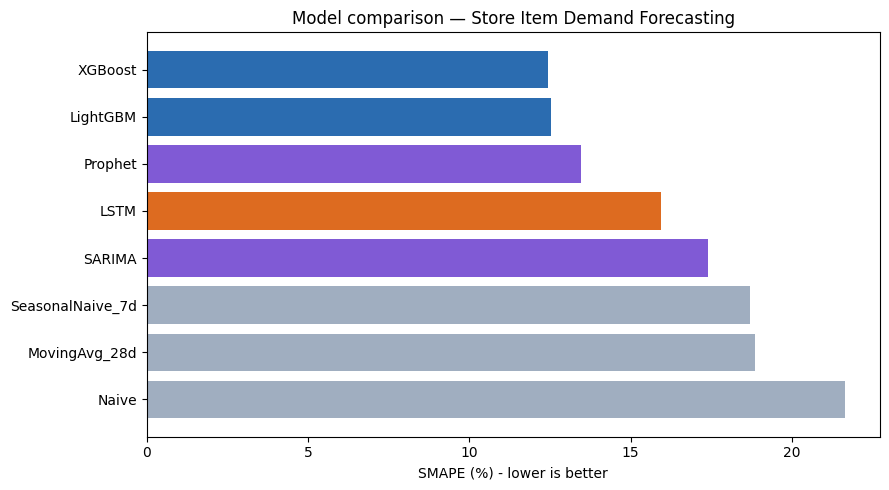

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
order = leaderboard.sort_values("SMAPE")
colors = {"baseline":"#a0aec0","classical":"#805ad5","gbm":"#2b6cb0","neural":"#dd6b20"}
ax.barh(order["model"], order["SMAPE"], color=[colors[t] for t in order["tier"]])
ax.set_xlabel("SMAPE (%) - lower is better"); ax.set_title("Model comparison — Store Item Demand Forecasting")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 8. What's next

Whichever model wins here (checking SMAPE first, MAE/RMSE for tie-breaks)
moves on to:
- **Hyperparameter tuning** (Optuna) on that model specifically
- **SHAP explainability** if it's LightGBM/XGBoost
- Fresh **MLOps layer**: drift detection, retraining pipeline, FastAPI serving
